In [1]:

import glob
import os
import warnings
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchmetrics.classification import (
    BinaryAUROC,
    BinaryConfusionMatrix
)
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score
from tqdm import tqdm

from models.first_model import AMIVADDataset, VADLightningModule
from models.second_model import AMISegmentationDataset, SpeakerSegmentationModel, AMISegmentationTask, \
    PermutationInvariantBCELoss
from models.third_model import SpeakerLightningModule, AMISpeakerDataModule

warnings.filterwarnings('ignore')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
C:\Users\gaszt\miniconda3\envs\NLP\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


# EDA

In [28]:
AUDIO_DIR = "./pyannote/amicorpus"
RTTM_BASE = "./only_words/rttms"
SPLITS = ["train", "dev", "test"]

RTTM_COLS = ["type", "file_id", "channel", "start", "duration", "ortho", "spk_type", "speaker_id", "conf", "slat"]


def parse_rttm_files():
    rttm_records = []

    for split in SPLITS:
        search_path = os.path.join(RTTM_BASE, split, "*.rttm")
        rttm_files = glob.glob(search_path)

        for file in rttm_files:
            with open(file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 8 and parts[0] == "SPEAKER":
                        rttm_records.append({
                            "split": split,
                            "file_id": parts[1],
                            "start": float(parts[3]),
                            "duration": float(parts[4]),
                            "speaker_id": parts[7]
                        })
    return pd.DataFrame(rttm_records)


def run_eda():
    df_rttm = parse_rttm_files()

    if df_rttm.empty:
        return

    print(f"Total Speech Turns (Annotations): {len(df_rttm)}")
    print(f"Total Unique Audio Files in RTTMs: {df_rttm['file_id'].nunique()}")
    print(f"Total Unique Speakers: {df_rttm['speaker_id'].nunique()}")

    speech_time_per_split = df_rttm.groupby('split')['duration'].sum() / 3600  # in hours
    print("\nTotal Speech Duration per Split (Hours):")
    print(speech_time_per_split.round(2))

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle("AMI Corpus Exploratory Data Analysis", fontsize=16)

    sns.countplot(data=df_rttm, x="split", order=SPLITS, ax=axes[0, 0], palette="viridis")
    axes[0, 0].set_title("Total Speech Turns per Split")
    axes[0, 0].set_ylabel("Number of Annotations")

    speech_per_file = df_rttm.groupby('file_id')['duration'].sum() / 60
    sns.histplot(speech_per_file, bins=30, kde=True, ax=axes[0, 1], color="mediumpurple")
    axes[0, 1].set_title("Total Active Speech per Meeting")
    axes[0, 1].set_xlabel("Total Speech Duration (Minutes)")
    axes[0, 1].set_ylabel("Number of Meetings")

    speakers_per_file = df_rttm.groupby('file_id')['speaker_id'].nunique()
    sns.histplot(speakers_per_file, discrete=True, ax=axes[1, 0], color="skyblue")
    axes[1, 0].set_title("Number of Unique Speakers per Audio File")
    axes[1, 0].set_xlabel("Unique Speakers")
    axes[1, 0].set_ylabel("Number of Files")

    sns.boxplot(data=df_rttm, x="split", y="duration", order=SPLITS, ax=axes[1, 1], palette="viridis", showfliers=False)
    axes[1, 1].set_title("Speech Turn Duration Boxplot per Split (Outliers Hidden)")
    axes[1, 1].set_ylabel("Duration (seconds)")

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

## Dataset analysis

Total Speech Turns (Annotations): 82973
Total Unique Audio Files in RTTMs: 170
Total Unique Speakers: 189

Total Speech Duration per Split (Hours):
split
dev       8.77
test      8.53
train    75.76
Name: duration, dtype: float64


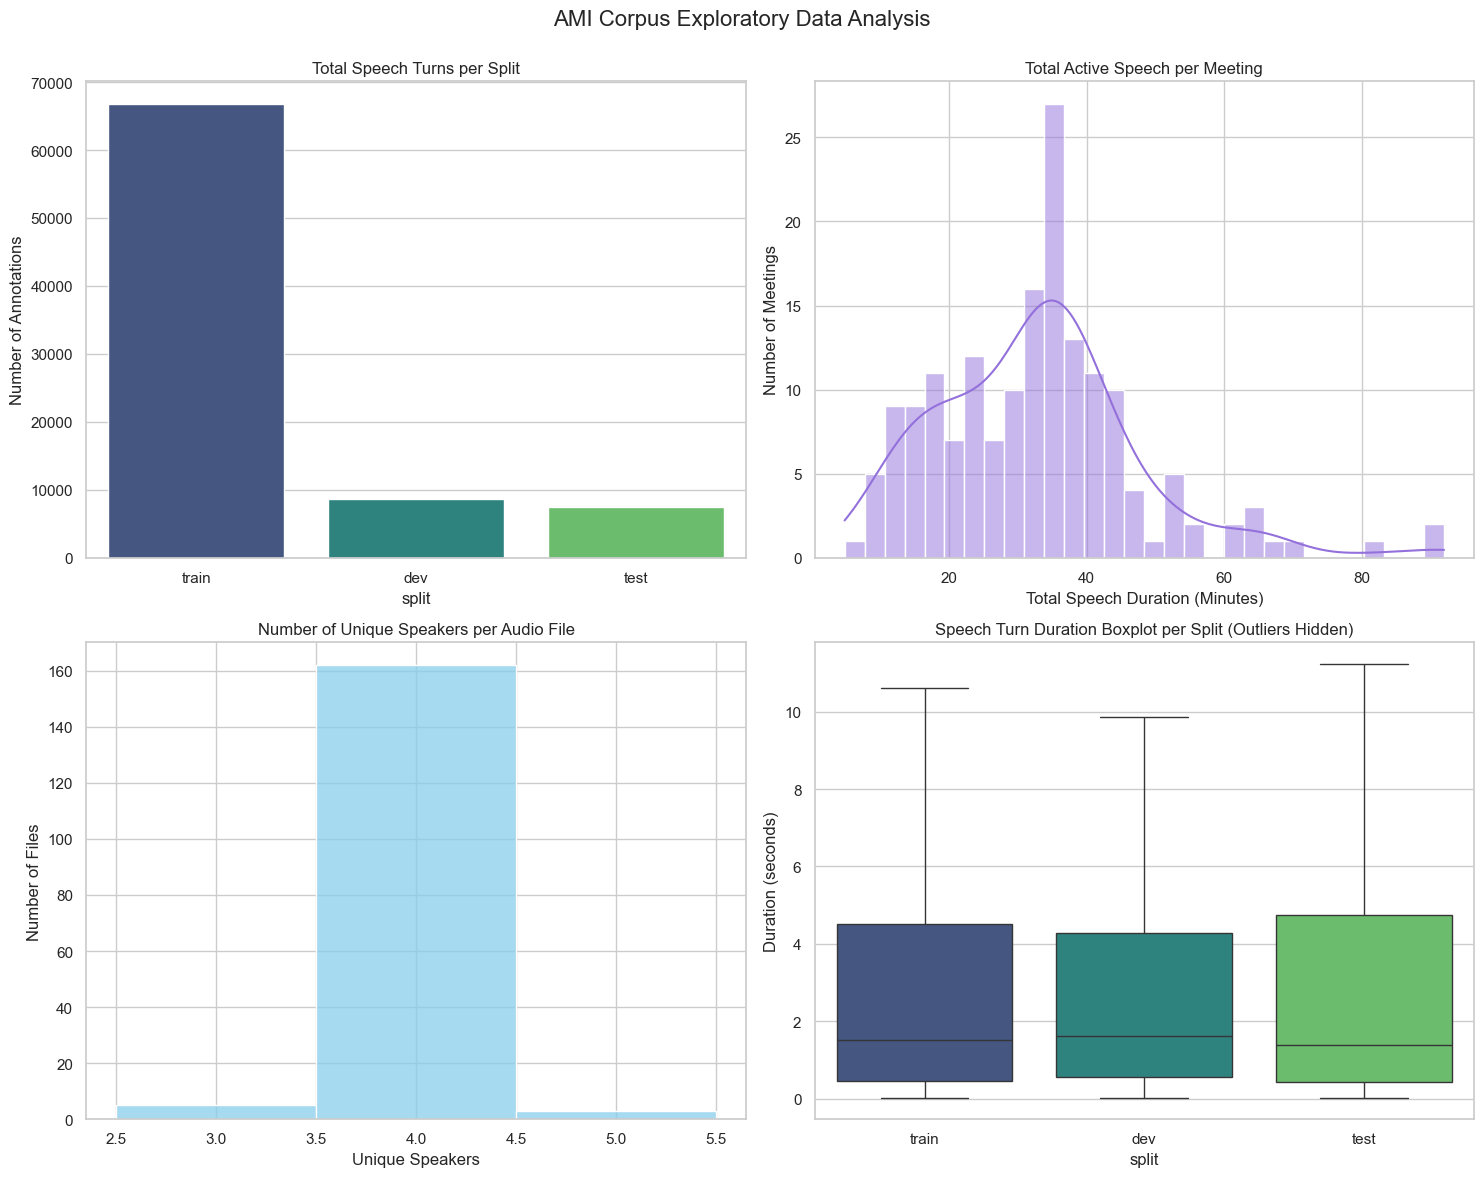

In [29]:
run_eda()


### Conclusion

As we can see from the analysis and plots the distribution of AMI dataset is around 80/10/10 split, which means good balance between training and test data. Second plot shows that each file contains 30 - 40 minutes of annotations. Most of the audio files contains 4 unique speakers with few of them containing either 3 or 5. From the last plot we can see that  duration of speech turns averages around 3 second median and around 5 seconds for 75th percentile, that means that this meetings are highly interactive probably with a lot of turns. 

In [32]:
def analyze_single_wav():
    search_path = os.path.join(AUDIO_DIR, "*.wav")
    audio_files = glob.glob(search_path)

    if not audio_files:
        return

    sample_file = audio_files[0]

    y, sr = librosa.load(sample_file, sr=None)

    duration_to_plot = 60
    samples_to_plot = sr * duration_to_plot
    y_segment = y[:samples_to_plot]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f"Acoustic Analysis (First 60s)", fontsize=16)

    librosa.display.waveshow(y_segment, sr=sr, ax=axes[0], color="steelblue")
    axes[0].set_title("Waveform (Amplitude over Time)")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_xlabel("Time (seconds)")

    n_fft = 2048
    hop_length = 512
    S = librosa.feature.melspectrogram(y=y_segment, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=128)

    S_dB = librosa.power_to_db(S, ref=np.max)

    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr,
                                   hop_length=hop_length, ax=axes[1], cmap='magma')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    axes[1].set_title("Mel-Spectrogram")

    plt.tight_layout()

    output_img = "single_wav_analysis.png"
    plt.savefig(output_img)
    plt.show()

## Audio file analysis

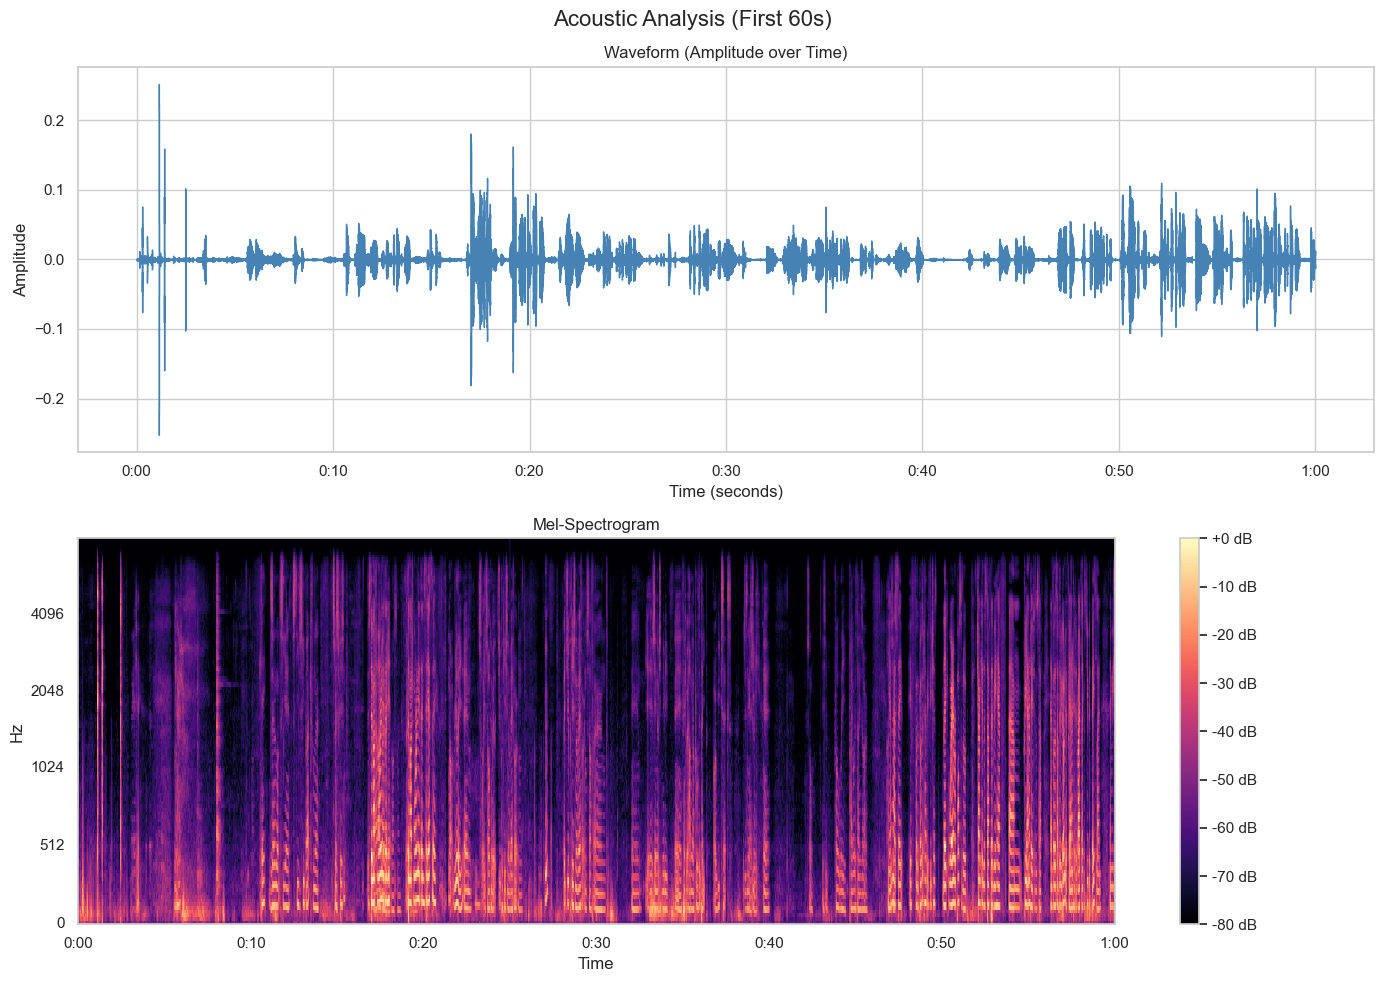

In [33]:
analyze_single_wav()

### Conclusion

From the Waveform plot we can see that in first 60 seconds of audiofile mostly contains short fragments of speech with exception of the end of file (around 47 seconds mark), with continuous speech until the end of fragment.
From mel-spectrogram we can see that overall data is really highly quality and will be easy for neural networks to process. Also in the pauses of upper plot we can see that it mostly white which means it has no background noise. 

# First Model

## Utils

In [2]:
def evaluate_model(checkpoint_path, audio_dir, test_rttm_dir, batch_size=32, device='cuda'):
    if device == 'cuda' and not torch.cuda.is_available():
        print("CUDA not available. Falling back to CPU.")
        device = 'cpu'
    device = torch.device(device)

    model = VADLightningModule.load_from_checkpoint(checkpoint_path)
    model.to(device)
    model.eval()

    test_dataset = AMIVADDataset(audio_dir=audio_dir, rttm_dir=test_rttm_dir)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    acc_metric = BinaryAccuracy().to(device)
    prec_metric = BinaryPrecision().to(device)
    rec_metric = BinaryRecall().to(device)
    f1_metric = BinaryF1Score().to(device)
    auroc_metric = BinaryAUROC().to(device)
    cm_metric = BinaryConfusionMatrix().to(device)

    with torch.no_grad():
        for waveforms, labels in tqdm(test_loader, desc="Testing"):
            waveforms = waveforms.to(device)
            labels = labels.to(device)

            logits = model(waveforms)

            if logits.shape[1] != labels.shape[1]:
                logits = torch.nn.functional.interpolate(
                    logits.unsqueeze(1), size=labels.shape[1], mode='linear'
                ).squeeze(1)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.6).int()
            labels_int = labels.int()

            preds_flat = preds.view(-1)
            labels_flat = labels_int.view(-1)
            probs_flat = probs.view(-1)

            acc_metric.update(preds_flat, labels_flat)
            prec_metric.update(preds_flat, labels_flat)
            rec_metric.update(preds_flat, labels_flat)
            f1_metric.update(preds_flat, labels_flat)
            auroc_metric.update(probs_flat, labels_flat)
            cm_metric.update(preds_flat, labels_flat)

    print("=" * 30)
    print(f"Frame-level Accuracy:  {acc_metric.compute().item():.4f}")
    print(f"Precision (Speech):    {prec_metric.compute().item():.4f}")
    print(f"Recall (Sensitivity):  {rec_metric.compute().item():.4f}")
    print(f"F1-Score:              {f1_metric.compute().item():.4f}")
    print(f"AUROC:                 {auroc_metric.compute().item():.4f}")
    print("=" * 30)

    cm = cm_metric.compute().cpu().numpy()
    plot_confusion_matrix(cm, save_path='confusion_matrix.png')


def plot_confusion_matrix(cm, save_path='confusion_matrix.png'):
    fig, ax = plt.subplots(figsize=(6, 6))
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.grid(False)

    classes = ['Non-Speech (0)', 'Speech (1)']
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title='Confusion Matrix',
           ylabel='True Label',
           xlabel='Predicted Label')

    fmt = '.2f'
    thresh = cm_norm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{format(cm_norm[i, j], fmt)}\n({cm[i, j]})",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black")

    fig.tight_layout()
    plt.show()


## Results

Testing: 100%|██████████| 510/510 [00:18<00:00, 26.89it/s]


Frame-level Accuracy:  0.9389
Precision (Speech):    0.9613
Recall (Sensitivity):  0.9628
F1-Score:              0.9621
AUROC:                 0.9794


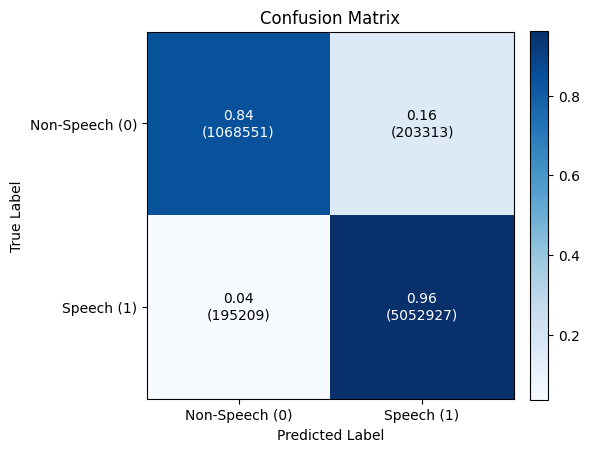

In [3]:
CHECKPOINT_PATH = './lightning_logs/first_model/checkpoints/vad-ami-epoch=01-val_f1=0.96.ckpt'
AUDIO_DIR = './pyannote/amicorpus'
TEST_RTTM_DIR = './only_words/rttms/test'

evaluate_model(
    checkpoint_path=CHECKPOINT_PATH,
    audio_dir=AUDIO_DIR,
    test_rttm_dir=TEST_RTTM_DIR,
    batch_size=64,
    device='cuda'
)

## Conclusion

As we can see from results our model demonstrates high effectiveness in speach detection task, but has distinct bias toward positive class due to class imbalance in dataset. Confusion matrix shows that 96% of Speech was correctly identified with 84% correct predictions on Non-Speech. This means our model probably sometimes over-predicts breathing or other background noise as speech.  Overall, depending on the task we can change decision threshold for more precise filtering of noise.

# Second model

## Utils

In [6]:
def run_evaluation(checkpoint_path, audio_dir, test_rttm_dir, batch_size=32, window_size=2.0, window_hop=1.0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    base_model = SpeakerSegmentationModel(num_speakers=4, sample_rate=16000)

    task = AMISegmentationTask.load_from_checkpoint(checkpoint_path, model=base_model)

    model = task.model
    model.to(device)
    model.eval()

    test_dataset = AMISegmentationDataset(
        audio_dir=audio_dir,
        rttm_dir=test_rttm_dir,
        window_size=window_size,
        window_hop=window_hop,
        max_speakers=task.num_speakers
    )
    print(test_dataset.max_speakers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    test_accuracy = BinaryAccuracy().to(device)
    test_precision = BinaryPrecision().to(device)
    test_recall = BinaryRecall().to(device)
    test_f1 = BinaryF1Score().to(device)

    speaker_f1s = [BinaryF1Score().to(device) for _ in range(task.num_speakers)]

    total_speech_frames = 0
    missed_speech_frames = 0
    false_alarm_frames = 0

    pit_loss_fn = PermutationInvariantBCELoss(num_speakers=task.num_speakers)

    with torch.no_grad():
        for waveforms, targets in tqdm(test_loader, desc="Evaluating"):
            waveforms = waveforms.to(device)
            targets = targets.to(device)

            preds = model(waveforms)

            if preds.size(1) != targets.size(1):
                preds = F.interpolate(preds.permute(0, 2, 1), size=targets.size(1), mode='linear').permute(0, 2, 1)

            _, aligned_targets = pit_loss_fn(preds, targets)
            preds_prob = torch.sigmoid(preds)

            preds_flat = preds_prob.reshape(-1)
            targets_flat = aligned_targets.reshape(-1)

            test_accuracy.update(preds_flat, targets_flat)
            test_precision.update(preds_flat, targets_flat)
            test_recall.update(preds_flat, targets_flat)
            test_f1.update(preds_flat, targets_flat)

            for spk_idx in range(task.num_speakers):
                speaker_f1s[spk_idx].update(preds_prob[:, :, spk_idx].reshape(-1),
                                            aligned_targets[:, :, spk_idx].reshape(-1))

            preds_bool = (preds_prob > 0.5)
            targets_bool = (aligned_targets == 1.0)

            total_speech_frames += torch.sum(targets_bool).item()
            missed_speech_frames += torch.sum(targets_bool & ~preds_bool).item()
            false_alarm_frames += torch.sum(~targets_bool & preds_bool).item()

    avg_acc = test_accuracy.compute().item()
    avg_prec = test_precision.compute().item()
    avg_rec = test_recall.compute().item()
    avg_f1 = test_f1.compute().item()

    spk_f1_scores = [metric.compute().item() for metric in speaker_f1s]
    macro_f1 = sum(spk_f1_scores) / len(spk_f1_scores)

    miss_rate = (missed_speech_frames / total_speech_frames) if total_speech_frames > 0 else 0.0
    fa_rate = (false_alarm_frames / total_speech_frames) if total_speech_frames > 0 else 0.0

    frame_der_proxy = miss_rate + fa_rate

    print(f"Global Accuracy:  {avg_acc * 100:.2f}%")
    print(f"Global Precision: {avg_prec * 100:.2f}%")
    print(f"Global Recall:    {avg_rec * 100:.2f}%")
    print(f"Global F1-Score:  {avg_f1 * 100:.2f}%")
    print(f"Macro F1-Score:   {macro_f1 * 100:.2f}%")
    print("-" * 50)
    print("Per-Speaker Output Slot Performance (F1-Score):")
    for i, score in enumerate(spk_f1_scores):
        print(f"  • Speaker Slot {i}: {score * 100:.2f}%")


## Results

In [7]:
CHECKPOINT_PATH = "./lightning_logs/version_20/checkpoints/epoch=3-step=36212.ckpt"
AUDIO_DIR = './pyannote/amicorpus'
TEST_RTTM_DIR = './only_words/rttms/test'

run_evaluation(
    checkpoint_path=CHECKPOINT_PATH,
    audio_dir=AUDIO_DIR,
    test_rttm_dir=TEST_RTTM_DIR
)

4


Evaluating: 100%|██████████| 1019/1019 [00:59<00:00, 17.00it/s]

Global Accuracy:  95.30%
Global Precision: 93.90%
Global Recall:    85.58%
Global F1-Score:  89.55%
Macro F1-Score:   46.81%
--------------------------------------------------
Per-Speaker Output Slot Performance (F1-Score):
  • Speaker Slot 0: 94.41%
  • Speaker Slot 1: 0.00%
  • Speaker Slot 2: 25.68%
  • Speaker Slot 3: 67.14%


## Conclusion

Despite having good general metrics model has big problems, like dead slot at speaker 1 and almost unusable slot at speaker 2. The problem is probably in the hyperparameters we chose, with 4 speakers per audio track and only 2 of them speaking per fragment of 6 seconds most of the time, which means our model learned lazy strategy by only using speaker slots 1 and 3 instead of applying all of them.

# Third model


## Utils

In [12]:
def run_similarity_test(checkpoint_path, audio_dir, val_rttm_dir, batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    data_module = AMISpeakerDataModule(
        audio_dir=audio_dir,
        train_rttm_dir=Path('./'),
        val_rttm_dir=val_rttm_dir,
        batch_size=batch_size,
        num_workers=0
    )
    data_module.setup(stage="validate")
    val_loader = data_module.val_dataloader()

    model = SpeakerLightningModule.load_from_checkpoint(checkpoint_path)
    model.to(device)
    model.eval()

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader):
            waveforms, labels = batch
            waveforms = waveforms.to(device)

            embeddings = model(waveforms)

            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)

    all_embeddings = torch.cat(all_embeddings, dim=0)  # [N, 256]
    all_labels = torch.cat(all_labels, dim=0)  # [N]

    num_samples = all_embeddings.size(0)

    similarity_matrix = torch.mm(all_embeddings, all_embeddings.t())  # [N, N]

    same_speaker_mask = (all_labels.unsqueeze(0) == all_labels.unsqueeze(1))

    diag_mask = torch.eye(num_samples, dtype=torch.bool)
    same_speaker_mask = same_speaker_mask & ~diag_mask
    diff_speaker_mask = ~same_speaker_mask & ~diag_mask

    same_speaker_sims = similarity_matrix[same_speaker_mask].numpy()
    diff_speaker_sims = similarity_matrix[diff_speaker_mask].numpy()

    print("\n" + "=" * 40)
    print("  COSINE SIMILARITY TEST RESULTS  ")
    print("=" * 40)

    print(f"Same Speaker (Positive Pairs) - Total: {len(same_speaker_sims)}")
    print(f"  Mean Similarity:   {np.mean(same_speaker_sims):.4f}")
    print(f"  Median Similarity: {np.median(same_speaker_sims):.4f}")
    print(f"  Std Deviation:     {np.std(same_speaker_sims):.4f}")
    print(f"  Min Similarity:    {np.min(same_speaker_sims):.4f}")
    print(f"  Max Similarity:    {np.max(same_speaker_sims):.4f}")

    print("-" * 40)

    print(f"Different Speakers (Negative Pairs) - Total: {len(diff_speaker_sims)}")
    print(f"  Mean Similarity:   {np.mean(diff_speaker_sims):.4f}")
    print(f"  Median Similarity: {np.median(diff_speaker_sims):.4f}")
    print(f"  Std Deviation:     {np.std(diff_speaker_sims):.4f}")
    print(f"  Min Similarity:    {np.min(diff_speaker_sims):.4f}")
    print(f"  Max Similarity:    {np.max(diff_speaker_sims):.4f}")

    print("=" * 40)

    plt.figure(figsize=(10, 6))

    if len(same_speaker_sims) > 0:
        plt.hist(same_speaker_sims, bins=50, alpha=0.6, density=True,
                 label='Same Speaker (Positives)', color='g', edgecolor='black')

    if len(diff_speaker_sims) > 0:
        plt.hist(diff_speaker_sims, bins=50, alpha=0.6, density=True,
                 label='Different Speakers (Negatives)', color='r', edgecolor='black')

    plt.title('Normalized Distribution of Cosine Similarities')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Density')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


## Results

100%|██████████| 483/483 [00:09<00:00, 49.95it/s]



  COSINE SIMILARITY TEST RESULTS  
Same Speaker (Positive Pairs) - Total: 17977620
  Mean Similarity:   0.3938
  Median Similarity: 0.4031
  Std Deviation:     0.2219
  Min Similarity:    -0.4867
  Max Similarity:    0.9780
----------------------------------------
Different Speakers (Negative Pairs) - Total: 220678532
  Mean Similarity:   0.0331
  Median Similarity: 0.0176
  Std Deviation:     0.1668
  Min Similarity:    -0.6362
  Max Similarity:    1.0000


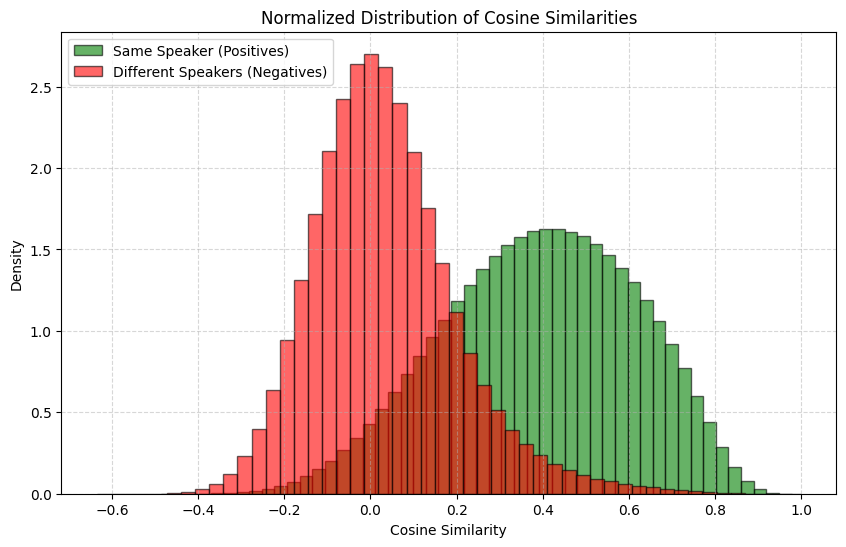

In [13]:
CHECKPOINT_PATH = "./lightning_logs/third_model/checkpoints/epoch=9-step=42660.ckpt"
AUDIO_DIR = './pyannote/amicorpus'
VAL_RTTM_DIR = './only_words/rttms/test'

run_similarity_test(
    checkpoint_path=CHECKPOINT_PATH,
    audio_dir=AUDIO_DIR,
    val_rttm_dir=VAL_RTTM_DIR,
    batch_size=32
)

## Conclusion

As we can see from metrics and plot there is defined difference between means of two distributions, however model still struggling from anomalies. The main problem with the results is high overlap area around 0.1 - 0.4 cosine similarity area which makes task of defining good threshold is very hard with tradeoffs in either side. The model still needs work, because in some cases it identifies negative pairs as 1 and positive as negative similarity.